# Face Recognition

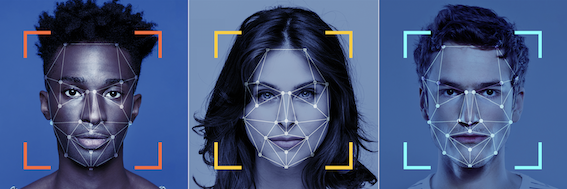

In this homework you'll dive into face recognition framework and train neural network for face recognition task, play with losses and metrics.

We will train neural network on [CelebA dataset](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html).

As you see on the site, images of celebA dataset look like this:


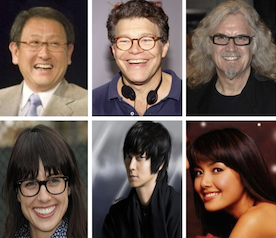

But we won't train a neural network for face recognition on those images. We'll need to preprocess them first. Let's see why we need it and how we need to preprocess them.

Let's look at how face recognition systems work:

## Face recognition model training and inference setup

This section describes how face recognition models are trained, what data alignment is and how the inference of face recognition model looks like. If you are familiar with this, you can skip this section.

### Model training

To train face recognition model on any facial dataset images must be aligned first. This step is very important to achieve a good quality of face recognition.

What is alignment: it consists of three steps:
1. Given image, identify facial landmarks on the image (coordinates of eyes, nose and mouth points). Separate neural network can be used there which was trained to identify landmarks on facial images. You can refer to [PyTorch Landmarks tutorial](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html) to see how this works.
2. Rotate all the images in the dataset so that eyes of the person on every image lie on a certain pre-defined horizontal line.
3. Scale all the images in the dataset so that the size of the faces are approximately identical.

Here's an example of what we would get after alignment of all the images of Aaron Peirsol from our dataset:

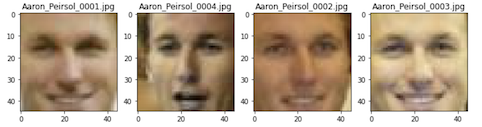

You see that eyes of all the faces lie on one horizontal line and all the faces have almost the same size. If we align all the images in the dataset, we can then train a neural network on aligned images.

**Why we need the alignment procedure**: the alignment of all faces in dataset makes the task of facial recognition easier for the model. If all the faces that model sees are of the same size and have their landmarks (eyes, nose, etc) on almost the same parts of the images, it is easier for the model to learn to identify a person on the image. The model diesn't need to "search" for the face and eyes positions on the image befire performing a recognition.

If you are interested, you can also train a model on non-aligned images, but you'll see that it would perform badly. It is possible though to train a model for face recognition without pre-alignment of all the faces, but this would require a huge amount of data — more that almost any company has. The only company that has openly presented its face recognition system that does not require special alignment is Facebook — their neural network was trained on a really huge amount of data using a special trick to avoid alignment. You can read more details [here](https://research.fb.com/publications/deepface-closing-the-gap-to-human-level-performance-in-face-verification/)

### Model inference

So let's see how the model trained on aligned faces can be used in real world:

Let's assume you owe a company and you want to build a face recognition system for your working office. You decided to hang some cameras around the office and want them to be able to recognize faces of all your employees when they are sitting / walking around the office (we let you decide by yourself why you would need such a system in your office)


A system for face recognition typically conststs of 3 stages:
- face detection
- face alignment
- face recognition

Let's discuss them in detail:

**Face detection**

When the camera is hanged on the wall it records a video and splits the video into single images, like this:

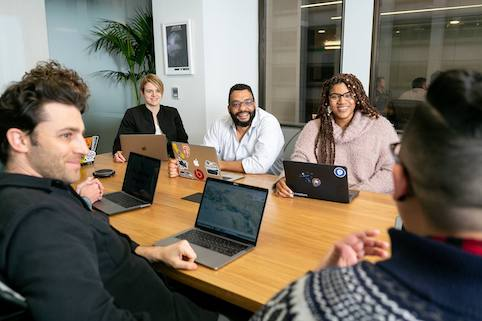

To be able to recognize all the faces on the photo you need first to detect all the faces that are present on the photo, like this:

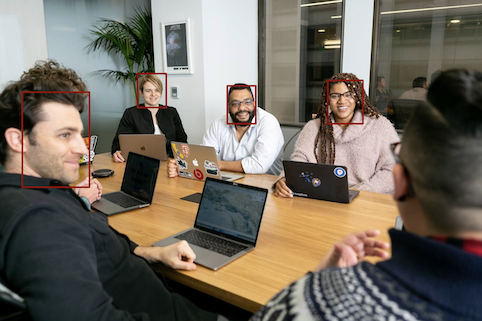

That is the first part — detection. You could use any neural network that can detect humans for this.

**Face alignment**

The second stage is to align all the faces found. The alignment procedure here should be the same as used to align training images.

So we'll get an image of a guy on a photo aligned like this:

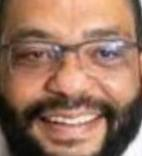

**Face recognition**

On the third stage we use the neural network that we trained to recognize a face.

So that's how the face recognition models pipeline work. You can also read about it more on [this link](https://www.nytimes.com/wirecutter/blog/how-facial-recognition-works/) (and using internet search)

## Neural network model architecture

Let's discuss how model for face recognition should look like.



The easiest and, actually, the most used way to build a neural network for face recognition is to build it as a **simple classifier**.

Assume we have a dataset with photos of N different people. Then we can build a neural network to classify all the images from the dataset into N classes. Each class refers to one unique person in the dataset.

**How do we recognize new people by this network then?** We actually want the network for face recognition to be able to recognize not only the people which are in training set, but almost every person in the world.

That is how: after training the model, we'll drop it's last classification layer. After that when we'll pass an image of the person through network, we'll get the output of the pre-last layer — it's **the embedding of the image**. Having embeddings of two different images we can compare them using **cosine distance**. The less the distance is — the higher the probability that those two photos belong to one person is.

Using that technique we can get embeddings of every image — even of unseen people, compare them, and reveal images belonging to same people.

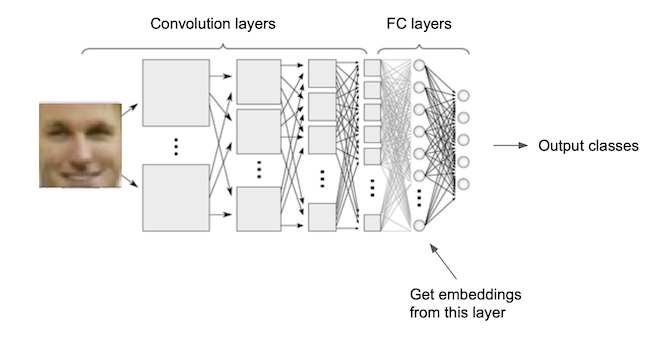

## Task 1 (4 points): build a neural network for faces classification as discribed above.

### Dataset

We will train out face recognition network on part of the [CelebA dataset](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html). But we'll use a version of it that has all the images in it aligned and cropped. You can download the dataset using this link: https://disk.yandex.ru/d/S8f03spLIA1wrw or using the code below:

In [ ]:
! pip install wldhx.yadisk-direct
! curl -L $(yadisk-direct https://disk.yandex.ru/d/S8f03spLIA1wrw) -o celebA_train.zip
! unzip -qq celebA_train.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100  162M  100  162M    0     0  15.0M      0  0:00:10  0:00:10 --:--:-- 21.6M


Let's look at the data first:

In [ ]:
! ls celebA_train_500/

celebA_anno.txt  celebA_imgs  celebA_train_split.txt


- celebA_imgs — folder with aligned images
- celebA_anno.txt — file with annotations: which person each image corresponds to
- celebA_train_split.txt — file with train/val/test info

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
from skimage import io, transform

import torch
from torch import nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from torchvision import models, transforms

import matplotlib.pyplot as plt

Let's visualize some images to understand what we're dealing with:

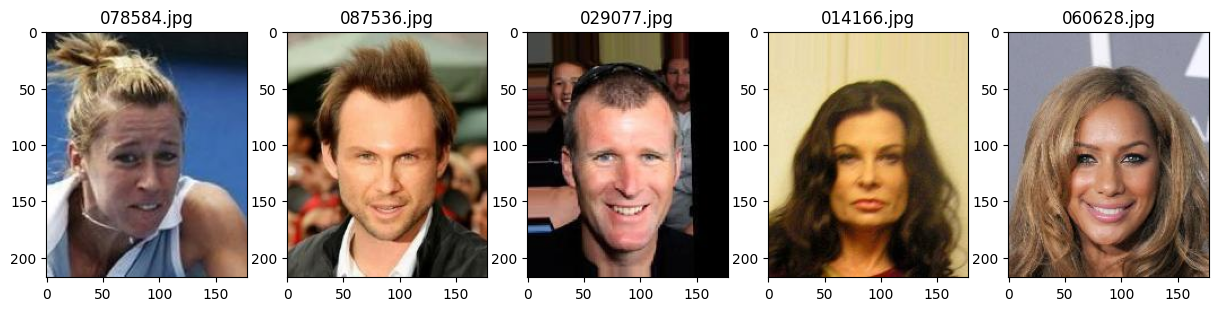

In [ ]:
def show_imgs(images_names):
    imgs = []
    for img in images_names:
      img = Image.open(os.path.join('celebA_train_500/celebA_imgs/', img))
      imgs.append(np.array(img))

    f, axes= plt.subplots(1, len(imgs), figsize=(3*len(imgs),5))
    for i, axis in enumerate(axes):
        axes[i].imshow(imgs[i], cmap='gray')
        axes[i].set_title(images_names[i])
    plt.show()

images_names = os.listdir('./celebA_train_500/celebA_imgs/')[:5]
show_imgs(images_names)


### Train Neural Network

Let's build a Datasets and network using this images:

In [ ]:
def get_paths(dataset_type='train'):
    '''
    a function that returnes list of images paths for a given type of the dataset
    params:
      dataset_type: one of 'train', 'val', 'test'
    '''

    labels_dict = {
        'train': 0,
        'val': 1,
        'test': 2,
    }

    f = open('celebA_train_500/celebA_train_split.txt', 'r')
    lines = f.readlines()
    f.close()

    lines = [x.strip().split() for x in lines]
    lines = [x[0] for x in lines if int(x[1]) == labels_dict[dataset_type]]

    images_paths = []
    for filename in lines:
        images_paths.append(os.path.join('celebA_train_500/celebA_imgs/', filename))

    return np.array(images_paths)


class CelebADataset(Dataset):
    """Feel free to rewrite it. For ex. cache all images in RAM to increase training speed"""
    def __init__(self, dataset_type, transform, aug=None,):
        self.images = get_paths(dataset_type=dataset_type)

        f = open('celebA_train_500/celebA_anno.txt', 'r')
        labels = f.readlines()
        f.close()
        labels = [x.strip().split() for x in labels]
        labels = {x:y for x, y in labels}
        self.labels = [int(labels[x.split('/')[-1]]) for x in self.images]

        self.transform = transform
        self.aug = aug

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        label = self.labels[idx]

        image = Image.open(img_name)

        if self.aug:
            sample = self.aug(
                image=image,
            )
        else:
            sample = {
                'image': image,
                'label': label,
            }

        sample['image'] = self.transform(sample['image'])

        return sample

In [ ]:
transform = transforms.Compose([
      # you may add anything, e.g. augmentation
      transforms.Resize(160),
      transforms.ToTensor(),
      transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

train_data = CelebADataset('train', transform)
val_data = CelebADataset('val', transform)
test_data = CelebADataset('test', transform)

# choose your own batch_size
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

Кое-что узнаем о датасете

In [ ]:
print(train_data[1])

{'image': tensor([[[ 1.7865,  1.7865,  1.7865,  ...,  1.2899,  1.3070,  1.3070],
         [ 1.7865,  1.7865,  1.7865,  ...,  1.2899,  1.3070,  1.3070],
         [ 1.7865,  1.7865,  1.7865,  ...,  1.2899,  1.3070,  1.3070],
         ...,
         [ 0.6906,  0.4679,  0.4166,  ..., -0.5253, -0.9363, -1.0904],
         [ 0.5364,  0.5536,  0.4851,  ..., -0.4568, -0.7650, -0.8849],
         [ 0.5022,  0.5707,  0.5022,  ..., -0.6109, -0.7650, -0.8164]],

        [[ 1.9034,  1.9034,  1.9034,  ...,  1.0280,  1.0455,  1.0455],
         [ 1.9034,  1.9034,  1.9034,  ...,  1.0280,  1.0455,  1.0455],
         [ 1.9034,  1.9034,  1.9034,  ...,  1.0280,  1.0455,  1.0455],
         ...,
         [ 0.4678,  0.2577,  0.2052,  ..., -0.7402, -1.1429, -1.2829],
         [ 0.3277,  0.3452,  0.2752,  ..., -0.6527, -0.9678, -1.0553],
         [ 0.2927,  0.3627,  0.2927,  ..., -0.8102, -0.9678, -0.9853]],

        [[ 1.9951,  1.9951,  1.9951,  ...,  0.8274,  0.8448,  0.8448],
         [ 1.9951,  1.9951,  1.9951

**Workflow**: train a model on train_data using val_data for validation. Use standard CE loss. Calculate the loss and accuracy on test set after training. Don't forget to log parameters, loss and metrics to Weights&biases e.g.

You may use whatever model you want, including pre-trained on ImageNet models from torchvision. Please note, that **it is not allowed to use pre-trained models on any other dataset except ImageNet**.

To get higher score, try to adjust hyperparameters, maybe try augmentations, etc.

Hints: Do not use too big model. Small ResNet-like network is enough to get the required score. Use at least 2 linear layers on the bottom. You'll need to drop the last layer after training and get image embeddings from the pre-last layer. It's not required to get the embedding from linear layer though: you may get it from last convolution layer, if you want.

**To get the whole mark for this section you need to achieve 70% accuracy on test set**.

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
from transformers import AdamW
from tqdm import tqdm, tqdm_notebook

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def get_classes():
    classes = np.hstack([train_data.labels, np.hstack([val_data.labels, test_data.labels])])
    return np.unique(classes)

In [ ]:
print(len(get_classes()))

500


In [ ]:
def get_new_fc(in_features):
    return nn.Sequential(
                    nn.Linear(in_features, len(get_classes())),
                    nn.BatchNorm1d(len(get_classes())),
                    nn.ReLU(inplace=True),
                    nn.Linear(len(get_classes()), len(get_classes()))
                    )

In [ ]:
def get_uppgrade_resnet():
    resnet18 = models.resnet18(pretrained=True)
    resnet18.fc = get_new_fc(resnet18.fc.in_features)
    return resnet18

In [ ]:
def train():
    epochs = 10
    model = get_uppgrade_resnet().to(device)
    optimizer = AdamW(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    best_score = 0
    for epoch in range(epochs):
        num_objects = 0
        correct_preds = 0
        total_loss = 0

        for batch in tqdm(train_loader):
            #print(X_batch)
            X_batch = batch['image'].to(device)
            y_batch = batch['label'].to(device)

            model.train()
            optimizer.zero_grad()
            y_pred = model(X_batch)

            loss = loss_fn(y_pred, y_batch)
            preds = torch.argmax(y_pred, 1)

            total_loss += loss.item() * X_batch.size(0)
            correct_preds += torch.sum(preds == y_batch)
            num_objects += X_batch.size(0)

            loss.backward()
            optimizer.step()

        loss_avg = total_loss/num_objects
        accuracy_avg = correct_preds.cpu().numpy()/num_objects

        print(f'Epoch: {epoch+1}, Loss: {loss_avg}, Accuracy:{accuracy_avg}')

    return model

In [ ]:
model = train()

100%|██████████| 134/134 [00:22<00:00,  5.86it/s]


Epoch: 1, Loss: 5.89200860820013, Accuracy:0.042485955056179775


100%|██████████| 134/134 [00:22<00:00,  5.86it/s]


Epoch: 2, Loss: 4.775461039739602, Accuracy:0.34691011235955055


100%|██████████| 134/134 [00:22<00:00,  5.84it/s]


...

Epoch: 8, Loss: 0.41873261857122074, Accuracy:0.9992977528089888


100%|██████████| 134/134 [00:22<00:00,  5.83it/s]


Epoch: 9, Loss: 0.22669698604930205, Accuracy:0.9995318352059925


100%|██████████| 134/134 [00:22<00:00,  6.07it/s]

Epoch: 10, Loss: 0.14034134869495135, Accuracy:0.9997659176029963


In [ ]:
torch.save(model.state_dict(), "fc_changed_model.pth")

Code for model evaluating (you can modify it if you want):

In [ ]:
def evaluate(model, dataloader, loss_fn):
    losses = []

    num_correct = 0
    num_elements = 0

    for i, batch in enumerate(dataloader):

        X_batch, y_batch = batch['image'], batch['label']
        num_elements += len(y_batch)

        with torch.no_grad():
            logits = model(X_batch.to(device))

            loss = loss_fn(logits, y_batch.to(device))
            losses.append(loss.item())

            y_pred = torch.argmax(logits, dim=1)

            num_correct += torch.sum(y_pred.cpu() == y_batch)

    accuracy = num_correct / num_elements

    return accuracy.numpy(), np.mean(losses)

In [ ]:
test_accuracy, test_loss = evaluate(model, test_loader, nn.CrossEntropyLoss() )
test_accuracy, test_loss

(array(0.5204531, dtype=float32), 2.9998014163970947)

**Cosine similarity calculation**: drop the last layer of trained network. Get embeddings for some images from train set and for images from test set. Calculate cosine similarities between embeddings corresponding to the pictures of the same person and different people. Is the difference big in any of cases?

In [ ]:
import random

In [ ]:
def get_embeddings(model, dataset, emb_count=5):
    model.eval()
    images = []
    embeddings = []

    idxs = random.sample(range(len(dataset)), emb_count)

    for idx in idxs:
        current_img = dataset[idx]['image'].unsqueeze(0).to(device)

        with torch.no_grad():
            emb = model(current_img).cpu().numpy()[0]
            embeddings.append(emb)
            images.append(current_img)

    return embeddings, images

In [ ]:
def get_random_images_of_same_person(dataset):
    all_labels = list(set(dataset.labels))
    label_rnd = random.choice(all_labels)

    idxs_with_label = []
    for i, label in enumerate(dataset.labels):
        if label == label_rnd:
            idxs_with_label.append(i)

    chosen_idxs = random.sample(idxs_with_label, 2)

    paths = [dataset.images[chosen_idxs[0]], dataset.images[chosen_idxs[1]]]
    return paths

In [ ]:
def get_random_images_of_different_person(dataset):
    all_labels = list(set(dataset.labels))
    label_rnd = random.choice(all_labels)

    idxs_with_label = []
    for i, label in enumerate(dataset.labels):
        if label != label_rnd:
            idxs_with_label.append(i)

    chosen_idxs = random.sample(idxs_with_label, 2)

    paths = [dataset.images[chosen_idxs[0]], dataset.images[chosen_idxs[1]]]
    return paths

In [ ]:
def calculate_cosine_similarity_for_same_person(model, dataset):
    paths = get_random_images_of_same_person(dataset)

    embeddings = []
    with torch.no_grad():
        for path in paths:
            img = dataset.transform(Image.open(path)).unsqueeze(0).to(device)
            embeddings.append(model(img).cpu().numpy()[0])

    sim = cosine_similarity([embeddings[0]], [embeddings[1]])[0, 0]
    return sim, paths

In [ ]:
def calculate_cosine_similarity_for_different_person(model, dataset):
    paths = get_random_images_of_different_person(dataset)

    embeddings = []
    with torch.no_grad():
        for path in paths:
            img = dataset.transform(Image.open(path)).unsqueeze(0).to(device)
            embeddings.append(model(img).cpu().numpy()[0])

    sim = cosine_similarity([embeddings[0]], [embeddings[1]])[0, 0]
    return sim, paths

In [ ]:
def plot_simularity_for_same():
    similarity_same, same_person_paths = calculate_cosine_similarity_for_same_person(get_model_without_fc(model), train_data)
    img1 = Image.open(same_person_paths[0])
    sim1 = similarity_same[0]
    img2 = Image.open(same_person_paths[1])
    sim2 = similarity_same[1]


    plt.subplot(1, 2, 1)
    plt.imshow(img)

    plt.subplot(1, 2, 2)
    plt.imshow(img)

    plt.show()

Train Embeddings:
Image 1: tensor([[[[ 2.2489,  2.2489,  2.2489,  ...,  2.0092,  1.9920,  1.9920],
          [ 2.2489,  2.2489,  2.2489,  ...,  2.0092,  1.9920,  1.9920],
          [ 2.2489,  2.2489,  2.2489,  ...,  2.0092,  1.9920,  1.9920],
          ...,
          [-1.6384, -1.6384, -1.6384,  ..., -1.5870, -1.5699, -1.5699],
          [-1.6384, -1.6384, -1.6384,  ..., -1.6042, -1.5699, -1.5528],
          [-1.6384, -1.6384, -1.6384,  ..., -1.6042, -1.5699, -1.5528]],

         [[ 2.4286,  2.4286,  2.4286,  ...,  2.0084,  1.9909,  1.9909],
          [ 2.4286,  2.4286,  2.4286,  ...,  2.0084,  1.9909,  1.9909],
          [ 2.4286,  2.4286,  2.4286,  ...,  2.0084,  1.9909,  1.9909],
          ...,
          [-1.5805, -1.5805, -1.5805,  ..., -1.5630, -1.5455, -1.5455],
          [-1.5805, -1.5805, -1.5805,  ..., -1.5805, -1.5455, -1.5280],
          [-1.5805, -1.5805, -1.5805,  ..., -1.5805, -1.5455, -1.5280]],

         [[ 2.6400,  2.6400,  2.6400,  ...,  2.2391,  2.2217,  2.2217],
   

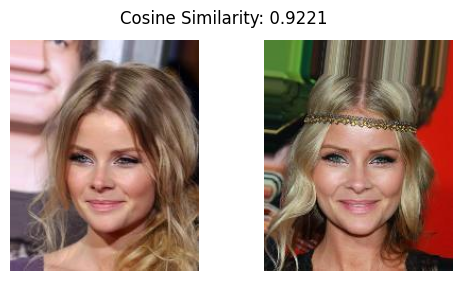

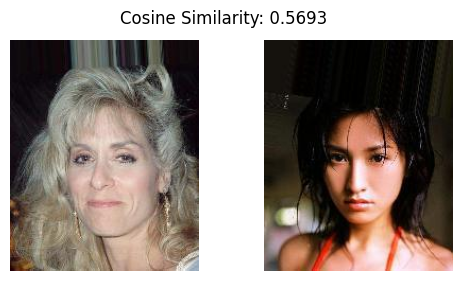

In [ ]:
train_embeddings, train_images = get_embeddings(get_model_without_fc(model), train_data)
test_embeddings, test_images = get_embeddings(get_model_without_fc(model), test_data)

# Визуализация случайных эмбеддингов
print("Train Embeddings:")
for i, emb in enumerate(train_embeddings):
    print(f"Image {i + 1}: {train_images[i]}, Embedding: {emb[:5]}...")

print("\nTest Embeddings:")
for i, emb in enumerate(test_embeddings):
    print(f"Image {i + 1}: {test_images[i]}, Embedding: {emb[:5]}...")

# Расчет косинусного расстояния для одного человека
similarity_same, same_person_images = calculate_cosine_similarity_for_same_person(get_model_without_fc(model), train_data)
similarity_different, different_person_images = calculate_cosine_similarity_for_different_person(get_model_without_fc(model), train_data)

# Визуализация изображений одного человека
plt.figure(figsize=(6, 3))
plt.suptitle(f"Cosine Similarity: {similarity_same:.4f}")
for i, img_path in enumerate(same_person_images):
    img = Image.open(img_path)
    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

# Визуализация изображений одного человека
plt.figure(figsize=(6, 3))
plt.suptitle(f"Cosine Similarity: {similarity_different:.4f}")
for i, img_path in enumerate(different_person_images):
    img = Image.open(img_path)
    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

====================================================================


**Cosine similarity distribution**: calculate all the cosine similarities between images in test dataset and train dataset of the same person. This means if you have image of person #106 in test dataset, calculate all similarities between this person's embeddings from test dataset and this person's embeddings from train dataset.

Then also do that for pairs of different people. This means if you have image of person #106 in test dataset, calculate similarities between this person's embeddings from test dataset and other people embeddings from train dataset.

Visualize (build histograms) the cosine similarities distributions for same and different people.

This calculation may take a long time and memory since it's a lot of pairs. You can cut the number of pairs which you calculate distances between. For example, use 1000-5000 examples.

In [ ]:
def calculate_cosine_similarity_distribution(model, train_dataset, test_dataset, num_pairs=1000):
    """
    Считает распределение косинусных расстояний между эмбеддингами одинаковых и разных людей.
    Параметры:
        model: torch.nn.Module, модель без слоя fc.
        train_dataset: объект Dataset (например, CelebADataset для train).
        test_dataset: объект Dataset (например, CelebADataset для test).
        num_pairs: количество пар для анализа.
    Возвращает:
        Два списка: расстояния для одинаковых и разных людей.
    """
    model.eval()

    # Получение эмбеддингов для всех изображений из train и test
    def get_all_embeddings(dataset):
        embeddings = {}
        for idx in range(len(dataset)):
            img_path = dataset.images[idx]
            label = dataset.labels[idx]
            img = Image.open(img_path)
            img_tensor = dataset.transform(img).unsqueeze(0).to(device)

            with torch.no_grad():
                embedding = model(img_tensor).cpu().numpy().flatten()
            if label not in embeddings:
                embeddings[label] = []
            embeddings[label].append(embedding)
        return embeddings

    train_embeddings = get_all_embeddings(train_dataset)
    test_embeddings = get_all_embeddings(test_dataset)

    # Расчет расстояний для одинаковых людей
    same_person_distances = []
    for _ in range(num_pairs):
        # Выбираем случайного человека из test и train
        person_id = random.choice(list(test_embeddings.keys()))
        if person_id in train_embeddings:
            test_embedding = random.choice(test_embeddings[person_id])
            train_embedding = random.choice(train_embeddings[person_id])

            # Считаем косинусное расстояние
            similarity = cosine_similarity([test_embedding], [train_embedding])[0, 0]
            same_person_distances.append(similarity)

    # Расчет расстояний для разных людей
    different_person_distances = []
    for _ in range(num_pairs):
        # Выбираем случайного человека из test
        test_person_id = random.choice(list(test_embeddings.keys()))
        test_embedding = random.choice(test_embeddings[test_person_id])

        # Выбираем случайного человека из train, который не совпадает
        train_person_id = random.choice(list(train_embeddings.keys()))
        while train_person_id == test_person_id:
            train_person_id = random.choice(list(train_embeddings.keys()))

        train_embedding = random.choice(train_embeddings[train_person_id])

        # Считаем косинусное расстояние
        similarity = cosine_similarity([test_embedding], [train_embedding])[0, 0]
        different_person_distances.append(similarity)

    return same_person_distances, different_person_distances


In [ ]:
def visualize_similarity_distributions(same_distances, different_distances):
    """
    Визуализирует распределения косинусных расстояний.
    Параметры:
        same_distances: список расстояний для одинаковых людей.
        different_distances: список расстояний для разных людей.
    """
    plt.figure(figsize=(12, 6))
    bins = np.linspace(-1, 1, 50)

    plt.hist(same_distances, bins, alpha=0.5, label='Same Person', color='green', density=True)
    plt.hist(different_distances, bins, alpha=0.5, label='Different People', color='red', density=True)

    plt.title("Cosine Similarity Distributions")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Density")
    plt.legend(loc="upper left")
    plt.show()


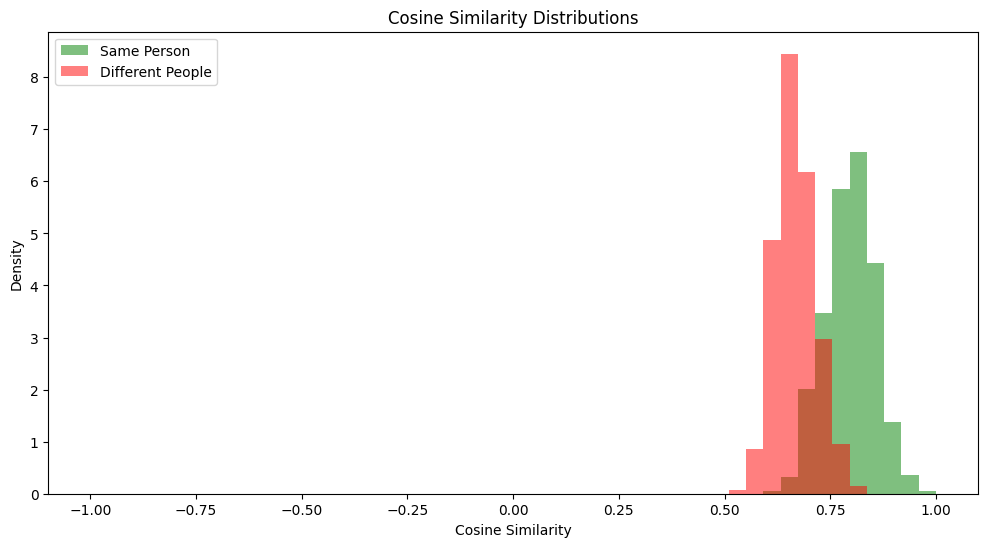

In [ ]:
# Вычисление распределений
same_distances, different_distances = calculate_cosine_similarity_distribution(
    get_model_without_fc(model), train_data, test_data, num_pairs=1000
)

# Визуализация
visualize_similarity_distributions(same_distances, different_distances)


## Task 2 (6 points): TripletLoss

Building a network on task 1 we used an ordinary CE loss. But there are many more variants of loss functions that can be used to train neural network. Examples of losses for face recognition and their performance reviews you can find in this paper: https://arxiv.org/pdf/1901.05903.pdf

This is another kind of loss which does not require a model to have last classification layer — it works directly with embeddings. It requires by design to make embeddings of one person be close on embeddings space and embeddings of different people be far away from each other.

This loss has an advantage over CE-like losses: it does not rely on number of classes in dataset. If we have new faces of new people in a dataset, we won't need to completely retrain the network, we could just fine-tune the trained network on new photos.


**How TripletLoss works**:

Here the architecture of neural network will be slightly different than it was when we used CE loss: it won't have the last classification layer. The last layer of NN will output embeddings of the given photo.

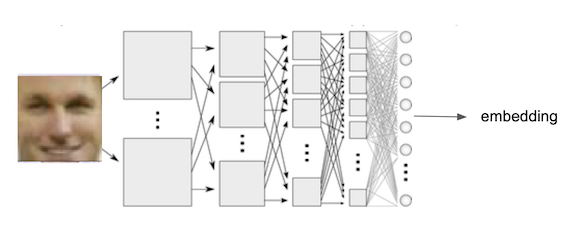

The TripletLoss function works directly with these embeddings. The idea of it is to make embeddings of the same people more close, compact in the embedding space, and the embeddings of the different people be more separate. There's a formula for the loss:

$$L(e, p, n) = max\{d(a, p) - d(a, n) + margin, 0\},$$

where
- $e$ is embedding of a photo (output of a model)
- $p$ is a positive embedding for the photo (embedding that we want $e$ be close to)
- $n$ is a negative embedding for the photo (embedding that we want $e$ be far from)
- $d(x, y)$ is a distance measure between embeddings
- margin — a positive margin to further boost the difference between $d(a, p)$ and $d(a, n)$

**All the embeddings $e$, $p$ and $n$ must be normalized before passing them to the loss**.

In our case for the given photo $E$ and it's embedding $e$ positive embedding $p$ must be an embedding of the photo of the same person and embedding $n$ must be an ambedding of the photo of the different person.

This emplementation of TripletLoss for PyTorch can be found [here](https://pytorch.org/docs/stable/generated/torch.nn.TripletMarginWithDistanceLoss.html#torch.nn.TripletMarginWithDistanceLoss). There are different variants of TripletLoss which can also boost performance and which you can implement by yourself, if you want:
- use more that 1 sample of $p$ and $n$ for one embedding $e$
- use special kinds of negatives: e.g. the negatives that are the most close to e (to boost them be further away from e)


**More to read about TripletLoss**:

The idea of TripletLoss: https://en.wikipedia.org/wiki/Triplet_loss

PyTorch implementation of TripletLoss: https://pytorch.org/docs/stable/generated/torch.nn.TripletMarginWithDistanceLoss.html#torch.nn.TripletMarginWithDistanceLoss

**Task**: implement a model and train it with TripletLoss. Play with margin parameter to achieve better results. Again, you might use whatever architecture you prefer, including ImageNet pre-trained networks. Do not use pre-trained networks on any other dataset. Don't forget to log parameters, loss and metrics to Weights&biases e.g.

Which loss among which you have tried is the best?

**To get the full mark for this task you need to train a model using  TripletLoss correctly at least for one value of margin and achieve >=70% acc on test set.**
As we don't have a classification layer in our network, we need a custom procedure for accuracy calculation. You can use one of the following procedures:
- calculate accuracy on val and test sets using KNN with embeddings from training set as training points. (easy way)
- compute mean embeddings for every class from training set and use them as reference embeddings.

**Hints**:
- think of what the distance function $d$ should be in our case: training a model we want it to output embeddings which can be compared using cosine similarity function. Pay attention to that cosine similarity is not a distance measure — the more cosine distance, the closer embeddings are. Think how you can put cosine distance into TripletLoss function.
- to train model using this loss you'll need to rewrite the Dataset class so it gives you not the random image and its label, but the image, positive images and negative images for this image;
- don't forget to normalize embeddings for the loss! You may even do that by adding batchnorm/layernorm to the last layer of your network
- `pytorch-metric-learning` library might be useful too

In [ ]:
# YOUR CODE HERE

## Bonus task (0.5 points): Finding trash photos

You have probably noticed that in identification rate calculation we use cosine similarity between embeddings, which includes embeddings' normalization. And in TripletLoss also we normalize embeddings before passing them to the loss. Actually this is how most of the face recognition algorithms work — they are designed to output a normalized embeddings and any comparison between embeddings is done after the embeddings are normalized. Sometimes it may be beneficial even to add a normalization layer (batchnorm or layernorm with fixed parameters) after the model's embedding layer to make the model output normalized embeddings.

But norms of the unnormalized embeddings can also be used. They can be used to detect trash photos — photos, where the face is presented really badly (e.g. back of the head instead of the forehead or even a photo without any head that has appeared in a dataset due to a mistake in face detection / landmarks detection algorithm).

Empirically it has been found that the higher the embedding's norm, the more the probability of the corresponding photo to be trash is.



**Task**: get the embeddings of photos in a test set. Sort them by their norms. Output the photos whose embeddings norms are the highest. Do they look like normal or trash?

**Doing this task will not give you points above 100% for the whole homework. But if you have any mistakes in previous sections, doing this task may save you 0.5 points.**

In [ ]:
# YOUR CODE HERE